# 54 — LSEG prospective batch ledger

**Objective.** Turn the immutable post-2026-06-26 LSEG headline batches into
one cumulative, licence-safe population record for the already-frozen
Gemma-26B-timed / FinBERT-ranked hybrid replay.

**Unit.** The scoring population is a unique normalized headline observed
strictly after the prospective cutoff. Source story IDs and raw rows remain
audit quantities, not scoring units.

**Success criterion.** Every registered batch passes source/spec/hash,
universe, contiguity, timestamp, and headline-only controls. The replay may
advance to separately authorised scoring only after at least 120 possible
XNYS sessions. The 60 active-session and 20-per-half gates remain sealed until
scoring. No price, return, or performance input is permitted here.

In [1]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "final_experiments":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.plots import CATEGORICAL, INK, apply_house_style  # noqa: E402
from final_experiments.lib.prospective import audit_prospective_registry  # noqa: E402
from sentiment_benchmark.artifact_io import sha256_file  # noqa: E402

NOTEBOOK_NAME = "54_lseg_prospective_batch_ledger.ipynb"
REGISTRY_PATH = (
    REPO_ROOT
    / "final_experiments/frozen_specs/"
    "lseg_gemma_finbert_hybrid_prospective_batch_registry_v1.json"
)
PARENT_SPEC_PATH = (
    REPO_ROOT
    / "final_experiments/frozen_specs/"
    "lseg_gemma_finbert_hybrid_prospective_v1.json"
)
OUTPUT_DIR = REPO_ROOT / "final_experiments/outputs/54_lseg_prospective_batch_ledger"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Planning reference from the completed expanded-44 Gemma run. This is not a
# quote and does not authorise another paid request.
REFERENCE_GEMMA_SUCCESS_COUNT = 888_155
REFERENCE_GEMMA_REPORTED_COST_USD = 33.61534475

apply_house_style()
pd.set_option("display.max_columns", 100)


def git_head() -> str:
    return subprocess.check_output(
        ["git", "rev-parse", "HEAD"], cwd=REPO_ROOT, text=True
    ).strip()

## Frozen plan

1. Audit the append-only registry and every local batch without exporting
   headline text.
2. Compare raw source rows with unique normalized and strictly eligible
   normalized headlines. This is a data/cost diagnostic, not an alpha test.
3. Evaluate only the calendar upper-bound gate. If it fails, stop before both
   scorers, prices, returns, and performance inference.
4. Persist aggregate tables, source hashes, a plot, and an explicit stop-state
   manifest so later batches extend rather than overwrite the evidence chain.

In [2]:
registry = json.loads(REGISTRY_PATH.read_text(encoding="utf-8"))
parent_spec = json.loads(PARENT_SPEC_PATH.read_text(encoding="utf-8"))
audit = audit_prospective_registry(REPO_ROOT, REGISTRY_PATH)

assert registry["controls"]["source_regime_pooling_permitted"] is False
assert registry["controls"]["paid_external_gemma_scoring_authorised"] is False
assert registry["controls"]["prices_or_returns_opened_by_registry_audit"] is False
assert not any("headline" == column for column in audit.batch_audit.columns)
assert not audit.batch_audit["licensed_headline_text_exported"].any()
assert not audit.batch_audit["story_bodies_requested"].any()
assert audit.batch_audit["unexpected_pagination_anomalies"].eq(0).all()

batch_columns = [
    "batch_order",
    "collection_id",
    "headline_rows",
    "unique_story_ids",
    "unique_normalized_headlines",
    "eligible_unique_story_ids",
    "eligible_unique_normalized_headlines",
    "duplicate_normalized_headline_rows",
    "empty_normalized_headline_rows",
    "strictly_post_cutoff_headlines",
    "exact_cutoff_headlines",
    "matched_symbols",
]
display(audit.batch_audit[batch_columns])

,batch_order,collection_id,headline_rows,unique_story_ids,unique_normalized_headlines,eligible_unique_story_ids,eligible_unique_normalized_headlines,duplicate_normalized_headline_rows,empty_normalized_headline_rows,strictly_post_cutoff_headlines,exact_cutoff_headlines,matched_symbols
0,1,us_sector_33_prospective_20260626_20260806_hea...,162123,162123,130742,162049,130692,31370,11,162049,74,33


In [3]:
display(audit.cumulative_audit)
display(audit.gate_table)

,through_batch_order,through_end_exclusive_utc,calendar_session_upper_bound,calendar_sessions_required,calendar_gate_pass,headline_rows_cumulative,unique_story_ids_cumulative,unique_normalized_headlines_cumulative,eligible_unique_story_ids_cumulative,eligible_unique_normalized_headlines_cumulative,matched_symbols_cumulative
0,1,2026-08-06T00:00:00+00:00,27,120,False,162123,162123,130742,162049,130692,33


,gate,required,observed_or_upper_bound,status,reason
0,complete_price_calendar_sessions,120,27,FAIL_BY_CALENDAR_UPPER_BOUND,"No scores, prices, or returns loaded; continue..."
1,primary_active_sessions,60,<NA>,NOT_EVALUATED_BEFORE_SCORING,Requires frozen Gemma and FinBERT event constr...
2,active_sessions_each_chronological_half,20,<NA>,NOT_EVALUATED_BEFORE_SCORING,Requires the scored primary strategy schedule.


## Population and spend diagnostic

The reference rate below is the realised average reported cost from the
completed 888,155-headline Gemma run. It is used only to size a possible
future authorisation; provider pricing and token mix can change. No spend is
incurred by this notebook.

In [4]:
latest_cumulative = audit.cumulative_audit.iloc[-1]
eligible_rows = int(audit.batch_audit["strictly_post_cutoff_headlines"].sum())
eligible_unique = int(
    latest_cumulative["eligible_unique_normalized_headlines_cumulative"]
)
normalization_request_reduction = 1.0 - eligible_unique / eligible_rows
reference_cost_per_success = (
    REFERENCE_GEMMA_REPORTED_COST_USD / REFERENCE_GEMMA_SUCCESS_COUNT
)
planning_cost_usd = eligible_unique * reference_cost_per_success

population_summary = pd.DataFrame(
    [
        {
            "registered_batches": len(audit.batch_audit),
            "source_rows": int(latest_cumulative["headline_rows_cumulative"]),
            "strictly_post_cutoff_source_rows_cumulative": eligible_rows,
            "eligible_unique_normalized_headlines": eligible_unique,
            "normalization_request_reduction_pct": 100
            * normalization_request_reduction,
            "reference_cost_per_success_usd": reference_cost_per_success,
            "planning_cost_at_reference_rate_usd": planning_cost_usd,
            "calendar_sessions_available": int(
                latest_cumulative["calendar_session_upper_bound"]
            ),
            "calendar_sessions_required": int(
                latest_cumulative["calendar_sessions_required"]
            ),
            "calendar_gate_pass": bool(latest_cumulative["calendar_gate_pass"]),
            "earliest_required_session": audit.earliest_required_session,
            "paid_gemma_authorised": False,
            "scoring_launched": False,
            "prices_or_returns_loaded": False,
        }
    ]
)
display(population_summary)

,registered_batches,source_rows,strictly_post_cutoff_source_rows_cumulative,eligible_unique_normalized_headlines,normalization_request_reduction_pct,reference_cost_per_success_usd,planning_cost_at_reference_rate_usd,calendar_sessions_available,calendar_sessions_required,calendar_gate_pass,earliest_required_session,paid_gemma_authorised,scoring_launched,prices_or_returns_loaded
0,1,162123,162049,130692,19.35032,0.000038,4.946498,27,120,False,2026-12-16,False,False,False


findfont: Failed to find font weight medium, now using 400.


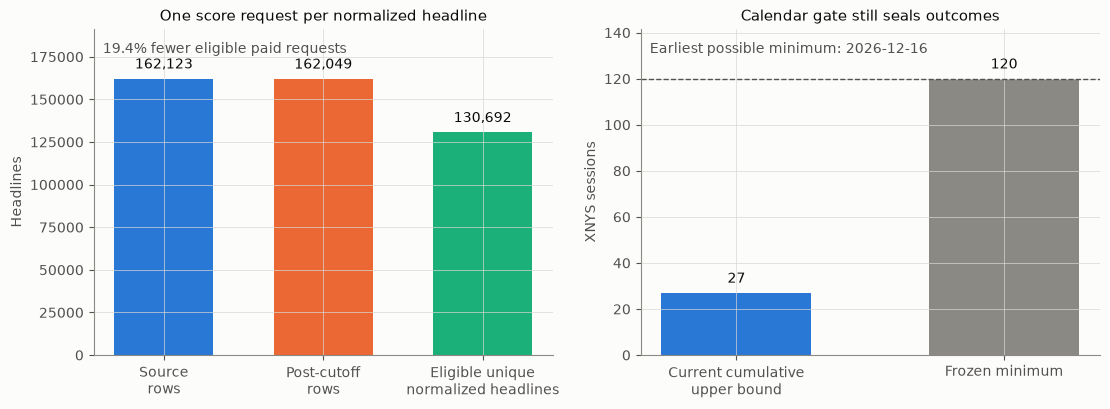

In [5]:
figure, axes = plt.subplots(1, 2, figsize=(11.2, 4.2))

population_labels = [
    "Source\nrows",
    "Post-cutoff\nrows",
    "Eligible unique\nnormalized headlines",
]
population_values = [
    int(latest_cumulative["headline_rows_cumulative"]),
    eligible_rows,
    eligible_unique,
]
population_bars = axes[0].bar(
    population_labels,
    population_values,
    color=[CATEGORICAL[0], CATEGORICAL[1], CATEGORICAL[2]],
    width=0.62,
)
axes[0].set_title("One score request per normalized headline")
axes[0].set_ylabel("Headlines")
for bar, value in zip(population_bars, population_values, strict=True):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        value + max(population_values) * 0.025,
        f"{value:,}",
        ha="center",
        va="bottom",
        color=INK["primary"],
    )
axes[0].text(
    0.02,
    0.96,
    f"{normalization_request_reduction:.1%} fewer eligible paid requests",
    transform=axes[0].transAxes,
    ha="left",
    va="top",
    color=INK["secondary"],
)
axes[0].set_ylim(0, max(population_values) * 1.18)

session_values = [
    int(latest_cumulative["calendar_session_upper_bound"]),
    int(latest_cumulative["calendar_sessions_required"]),
]
session_bars = axes[1].bar(
    ["Current cumulative\nupper bound", "Frozen minimum"],
    session_values,
    color=[CATEGORICAL[0], INK["muted"]],
    width=0.56,
)
axes[1].set_title("Calendar gate still seals outcomes")
axes[1].set_ylabel("XNYS sessions")
axes[1].axhline(
    session_values[1], color=INK["reference"], linestyle="--", linewidth=1
)
for bar, value in zip(session_bars, session_values, strict=True):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        value + 3,
        f"{value}",
        ha="center",
        va="bottom",
        color=INK["primary"],
    )
axes[1].text(
    0.02,
    0.96,
    f"Earliest possible minimum: {audit.earliest_required_session}",
    transform=axes[1].transAxes,
    ha="left",
    va="top",
    color=INK["secondary"],
)
axes[1].set_ylim(0, session_values[1] * 1.18)

figure.tight_layout()
figure_path = OUTPUT_DIR / "population_and_calendar_gate.png"
figure.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()

In [6]:
calendar_status = (
    "PASS_TO_SEPARATELY_AUTHORISED_SCORING_STAGE"
    if audit.calendar_gate_pass
    else "STOP_AND_CONTINUE_IMMUTABLE_ACCUMULATION"
)
display(
    Markdown(
        f"**Decision: {calendar_status}.** The registry contains "
        f"**{eligible_unique:,}** eligible unique normalized headlines, a "
        f"**{normalization_request_reduction:.1%}** request reduction relative "
        f"to scoring every eligible source story. At the prior realised average "
        f"Gemma rate this population would be about **${planning_cost_usd:,.2f}**, "
        "but paid scoring is not authorised. The calendar upper bound is "
        f"**{session_values[0]}/{session_values[1]}**; no scorer, price, return, "
        "or performance inference is opened."
    )
)

**Decision: STOP_AND_CONTINUE_IMMUTABLE_ACCUMULATION.** The registry contains **130,692** eligible unique normalized headlines, a **19.4%** request reduction relative to scoring every eligible source story. At the prior realised average Gemma rate this population would be about **$4.95**, but paid scoring is not authorised. The calendar upper bound is **27/120**; no scorer, price, return, or performance inference is opened.

## Persist aggregate evidence

These files contain counts, dates, booleans, and hashes only. Licensed
headline text remains in ignored local source files.

In [7]:
batch_path = OUTPUT_DIR / "batch_audit.csv"
cumulative_path = OUTPUT_DIR / "cumulative_audit.csv"
gate_path = OUTPUT_DIR / "population_gate.csv"
summary_path = OUTPUT_DIR / "population_summary.csv"
source_hashes_path = OUTPUT_DIR / "source_hashes.csv"
manifest_path = OUTPUT_DIR / "manifest.json"

audit.batch_audit.to_csv(batch_path, index=False, lineterminator="\n")
audit.cumulative_audit.to_csv(cumulative_path, index=False, lineterminator="\n")
audit.gate_table.to_csv(gate_path, index=False, lineterminator="\n")
population_summary.to_csv(summary_path, index=False, lineterminator="\n")
audit.source_hashes.to_csv(source_hashes_path, index=False, lineterminator="\n")

manifest = {
    "schema_version": 1,
    "status": (
        "population_gate_passed_but_scoring_not_authorised"
        if audit.calendar_gate_pass
        else "stopped_before_scoring_prices_and_returns"
    ),
    "notebook": NOTEBOOK_NAME,
    "git_commit_at_execution": git_head(),
    "candidate_rq": parent_spec["candidate_rq"],
    "registry": {
        "path": str(REGISTRY_PATH.relative_to(REPO_ROOT)),
        "sha256": sha256_file(REGISTRY_PATH),
        "registered_batches": len(audit.batch_audit),
    },
    "population": {
        "eligible_unique_normalized_headlines": eligible_unique,
        "eligible_normalized_population_sha256": audit.population_sha256,
        "eligible_story_population_sha256": audit.story_population_sha256,
        "normalization_request_reduction": normalization_request_reduction,
        "matched_symbols": int(latest_cumulative["matched_symbols_cumulative"]),
    },
    "planning_cost": {
        "reference_population": REFERENCE_GEMMA_SUCCESS_COUNT,
        "reference_reported_cost_usd": REFERENCE_GEMMA_REPORTED_COST_USD,
        "reference_cost_per_success_usd": reference_cost_per_success,
        "current_population_at_reference_rate_usd": planning_cost_usd,
        "quote_or_authorisation": False,
    },
    "population_gate": {
        "calendar_session_upper_bound": session_values[0],
        "required_calendar_sessions": session_values[1],
        "calendar_gate_pass": audit.calendar_gate_pass,
        "earliest_possible_required_session": audit.earliest_required_session,
        "active_session_gates_evaluated": False,
    },
    "stop_controls": {
        "finbert_scoring_launched": False,
        "paid_external_gemma_scoring_authorised": False,
        "paid_external_gemma_scoring_launched": False,
        "price_data_loaded": False,
        "returns_loaded": False,
        "performance_inference_run": False,
        "fnspid_pooling": False,
    },
    "sharing": {
        "contains_licensed_headline_text": False,
        "aggregate_only": True,
    },
    "outputs": {},
    "source_hashes": audit.source_hashes.to_dict(orient="records"),
}

for output_path in (
    batch_path,
    cumulative_path,
    gate_path,
    summary_path,
    source_hashes_path,
    figure_path,
):
    manifest["outputs"][output_path.name] = {
        "sha256": sha256_file(output_path),
        "bytes": output_path.stat().st_size,
    }
manifest_path.write_text(
    json.dumps(manifest, indent=2, sort_keys=True) + "\n", encoding="utf-8"
)

display(
    pd.DataFrame(
        [
            {"artifact": path.name, "sha256": sha256_file(path)}
            for path in (
                batch_path,
                cumulative_path,
                gate_path,
                summary_path,
                source_hashes_path,
                figure_path,
                manifest_path,
            )
        ]
    )
)

,artifact,sha256
0,batch_audit.csv,f84543797f12531e84e4b3ba5368a848bbfd98b37032de...
1,cumulative_audit.csv,381a14e43ba45203394413b27af1ec10d2bacf7f67b135...
2,population_gate.csv,451160a8f8d86f1102e786c462274f7d7a5452962b194a...
3,population_summary.csv,33bb3b5a56aa8adca18ebb48d5453d15ae6540304071fe...
4,source_hashes.csv,9a4586060a82a296206886f26f4f52d60b132e50b55ca7...
5,population_and_calendar_gate.png,13fa89da1b7d0f11d65329612b6931cc5fcd26cc880da9...
6,manifest.json,dd52cbe82cf50edb9f85b04deb16e2046ccb602bdadead...


## Next step

Append the next pre-retrieval acquisition spec and its completed local batch
to the registry without changing prior entries. Rerun this notebook. Only
when the 120-session calendar gate passes may a separately authorised scoring
stage evaluate the 60-active-session and 20-per-half gates; prices and returns
remain sealed until the complete scored population also passes those gates.